In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/enriched.csv', parse_dates=['transaction_date', 'transaction_timestamp'])
print(df.shape)
df.head()

(10000, 23)


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,...,merchant_id,device_id,account_balance,amount_zscore_client,hours_since_last_txn,is_new_merchant_for_client,is_new_device_for_client,is_unusual_hour_for_client,amount_pct_of_balance,risky_combo_flag
0,6546,16.21,0,Electronics,0,0,39,6,67,1,...,Electronics_M33,DEV_NEW_18317,4184.65,-0.884181,-1.0,1,1,1,0.003874,0
1,4679,204.63,0,Clothing,0,1,51,2,51,0,...,Clothing_M2,DEV_762,3321.82,-0.220208,-1.0,1,1,0,0.061602,0
2,6927,92.86,0,Electronics,0,0,92,2,38,0,...,Electronics_M14,DEV_12,18820.51,1.023366,-1.0,1,1,0,0.004934,0
3,4200,172.80,0,Food,0,1,51,3,56,0,...,Food_M21,DEV_498,7715.69,-0.106664,-1.0,1,1,1,0.022396,0
4,2579,79.72,0,Food,0,0,38,0,44,0,...,Food_M13,DEV_232,3325.92,-0.558748,-1.0,1,1,1,0.023969,0


In [3]:
df.info()
print("\nTaux de fraude global:", df['is_fraud'].mean())
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   transaction_id              10000 non-null  int64         
 1   amount                      10000 non-null  float64       
 2   transaction_hour            10000 non-null  int64         
 3   merchant_category           10000 non-null  str           
 4   foreign_transaction         10000 non-null  int64         
 5   location_mismatch           10000 non-null  int64         
 6   device_trust_score          10000 non-null  int64         
 7   velocity_last_24h           10000 non-null  int64         
 8   cardholder_age              10000 non-null  int64         
 9   is_fraud                    10000 non-null  int64         
 10  customer_id                 10000 non-null  str           
 11  transaction_date            10000 non-null  datetime64[us]
 12  tr

transaction_id                0
amount                        0
transaction_hour              0
merchant_category             0
foreign_transaction           0
location_mismatch             0
device_trust_score            0
velocity_last_24h             0
cardholder_age                0
is_fraud                      0
customer_id                   0
transaction_date              0
transaction_timestamp         0
merchant_id                   0
device_id                     0
account_balance               0
amount_zscore_client          0
hours_since_last_txn          0
is_new_merchant_for_client    0
is_new_device_for_client      0
is_unusual_hour_for_client    0
amount_pct_of_balance         0
risky_combo_flag              0
dtype: int64

In [4]:
features_to_check = ['is_new_device_for_client', 'is_new_merchant_for_client',
                      'is_unusual_hour_for_client', 'risky_combo_flag',
                      'foreign_transaction', 'location_mismatch']

for col in features_to_check:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['is_fraud'].mean())


--- is_new_device_for_client ---
is_new_device_for_client
0    0.005602
1    0.015452
Name: is_fraud, dtype: float64

--- is_new_merchant_for_client ---
is_new_merchant_for_client
0    0.02183
1    0.01419
Name: is_fraud, dtype: float64

--- is_unusual_hour_for_client ---
is_unusual_hour_for_client
0    0.014378
1    0.015497
Name: is_fraud, dtype: float64

--- risky_combo_flag ---
risky_combo_flag
0    0.013942
1    0.127451
Name: is_fraud, dtype: float64

--- foreign_transaction ---
foreign_transaction
0    0.007648
1    0.083845
Name: is_fraud, dtype: float64

--- location_mismatch ---
location_mismatch
0    0.008640
1    0.084014
Name: is_fraud, dtype: float64


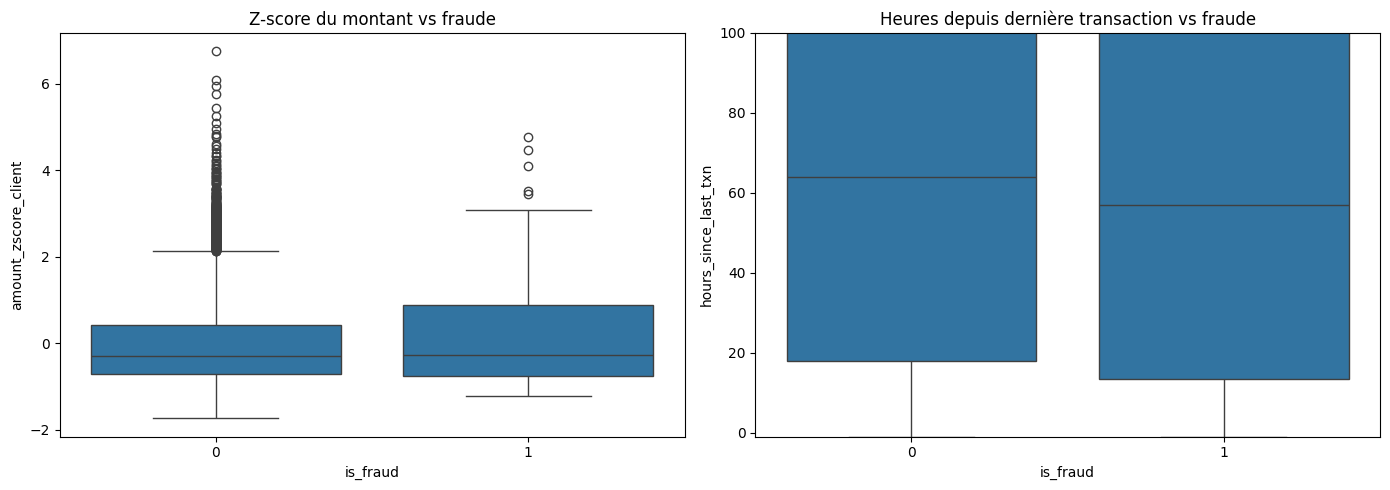

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='is_fraud', y='amount_zscore_client', ax=axes[0])
axes[0].set_title('Z-score du montant vs fraude')

sns.boxplot(data=df, x='is_fraud', y='hours_since_last_txn', ax=axes[1])
axes[1].set_ylim(-1, 100)
axes[1].set_title('Heures depuis dernière transaction vs fraude')

plt.tight_layout()
plt.show()

In [6]:
print("Dates min/max:", df['transaction_date'].min(), "->", df['transaction_date'].max())
print("Transactions avec hours_since_last_txn négatif:", (df['hours_since_last_txn'] < -1).sum())
print("Doublons transaction_id:", df['transaction_id'].duplicated().sum())

Dates min/max: 2026-01-01 00:00:00 -> 2026-06-29 00:00:00
Transactions avec hours_since_last_txn négatif: 0
Doublons transaction_id: 0


In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()['is_fraud'].sort_values(ascending=False)
print(corr)

is_fraud                      1.000000
foreign_transaction           0.185597
location_mismatch             0.173009
velocity_last_24h             0.103413
risky_combo_flag              0.093523
amount_zscore_client          0.028572
amount                        0.028404
amount_pct_of_balance         0.023244
is_new_device_for_client      0.014985
hours_since_last_txn          0.005868
is_unusual_hour_for_client    0.004387
account_balance               0.002301
cardholder_age               -0.000590
transaction_id               -0.010155
is_new_merchant_for_client   -0.020293
device_trust_score           -0.137913
transaction_hour             -0.138665
Name: is_fraud, dtype: float64
